<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_sa_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S. aureus - Filtering

### By: Mukundan Thanigaivelan

#### July 9, 2026

In this notebook, we filter S. aureus genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

The data have already been log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 591, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 591 (delta 50), reused 32 (delta 32), pack-reused 526 (from 2)
Receiving objects: 100% (591/591), 52.87 MiB | 33.15 MiB/s, done.
Resolving deltas: 100% (300/300), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

## 2. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import re
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. Data filtering

Here we are looking at S. aureus genes, with expression that has been log transformed and scaled to be between 0 and 1.

### Preparation

In [8]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sapg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [9]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 8961 genes (features) and 3737 samples


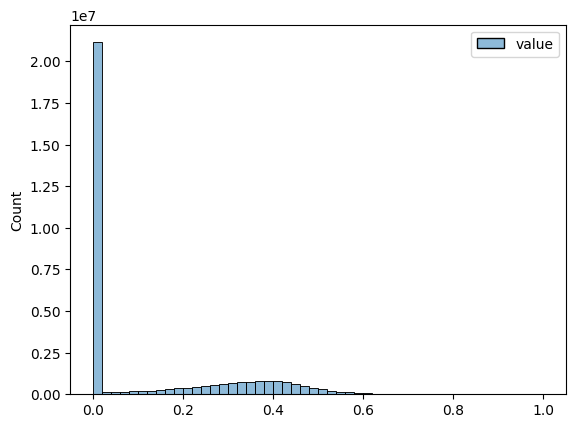

In [10]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

### Gene-wise Filtering

In [11]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
12b493b74dec297122c11824ed05ba01_1000,3737.0,0.488977,0.026861,0.368983,0.473390,0.489876,0.504804,0.611240
12b493b74dec297122c11824ed05ba01_1002,3737.0,0.549838,0.059249,0.227893,0.516761,0.551270,0.586811,0.939061
12b493b74dec297122c11824ed05ba01_1004,3737.0,0.363523,0.034345,0.000000,0.344430,0.363432,0.384248,0.503254
12b493b74dec297122c11824ed05ba01_1006,3737.0,0.462550,0.031850,0.318882,0.442544,0.462511,0.481403,0.609086
12b493b74dec297122c11824ed05ba01_1008,3737.0,0.421639,0.030869,0.324687,0.403107,0.421128,0.438587,0.568538


Text(0.5, 1.0, 'Mean vs. Median expression')

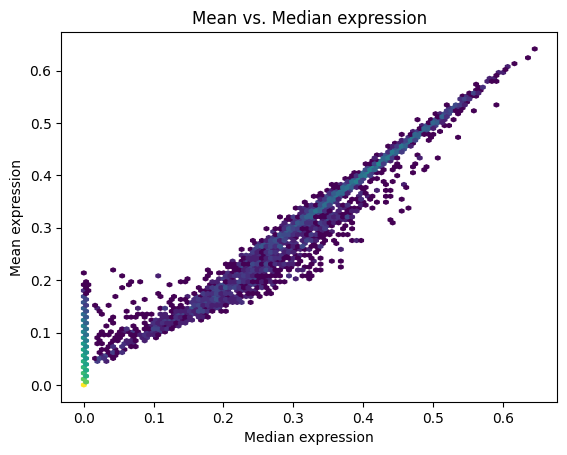

In [12]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log'
  # bins = 'log',
  # xscale = 'log',
  # yscale = 'log'
)

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")